# Project 3 — Mini Language Model

> **Transformer Mastery • Project Track**

This notebook is designed as an end-to-end, reproducible learning artifact: clear goals → implementation → experiments → diagnostics → conclusions.

In [1]:
import math, random, re, time
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt

SEED = 32
random.seed(SEED)
np.random.seed(SEED)

try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    torch.manual_seed(SEED)
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
except ImportError as e:
    raise ImportError("Install PyTorch first: pip install torch") from e

print("PyTorch:", torch.__version__)
print("Device:", DEVICE)


PyTorch: 2.11.0+cu128
Device: cuda


## 1. Mini Language Model

**Goal:** train a tiny causal Transformer to predict the next character. Character-level modeling keeps the tokenizer transparent and makes the complete pipeline easy to inspect.

In [2]:
corpus = (
    "the quick brown fox jumps over the lazy dog. "
    "the fox is quick and the dog is lazy. "
) * 300

chars = sorted(set(corpus))
stoi = {c:i for i,c in enumerate(chars)}
itos = {i:c for c,i in stoi.items()}
encoded = torch.tensor([stoi[c] for c in corpus], dtype=torch.long)

split = int(0.9 * len(encoded))
train_ids, val_ids = encoded[:split], encoded[split:]
BLOCK = 64
BATCH = 64

def get_batch(split="train"):
    src = train_ids if split=="train" else val_ids
    starts = torch.randint(0, len(src)-BLOCK-1, (BATCH,))
    x = torch.stack([src[i:i+BLOCK] for i in starts])
    y = torch.stack([src[i+1:i+BLOCK+1] for i in starts])
    return x.to(DEVICE), y.to(DEVICE)

print("Characters:", len(chars), "Train tokens:", len(train_ids))


Characters: 28 Train tokens: 22410


In [3]:
class MiniGPT(nn.Module):
    def __init__(self, vocab, d_model=128, heads=4, layers=3, dropout=0.1):
        super().__init__()
        self.tok = nn.Embedding(vocab, d_model)
        self.pos = nn.Embedding(BLOCK, d_model)
        layer    = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=heads, dim_feedforward=4*d_model,
            dropout=dropout, batch_first=True, activation="gelu"
        )
        self.blocks = nn.TransformerEncoder(layer, num_layers=layers)
        self.ln = nn.LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab, bias=False)
        self.lm_head.weight = self.tok.weight  # weight tying

    def forward(self, x, targets=None):
        T      = x.size(1)
        pos    = torch.arange(T, device=x.device)
        h      = self.tok(x) + self.pos(pos)[None,:,:]
        causal = torch.triu(torch.ones(T,T,device=x.device,dtype=torch.bool), diagonal=1)
        h      = self.blocks(h, mask=causal)
        logits = self.lm_head(self.ln(h))
        loss   = None
        if targets is not None:
            loss = F.cross_entropy(logits.reshape(-1, logits.size(-1)), targets.reshape(-1))
        return logits, loss

model     = MiniGPT(len(chars)).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)
print("Parameters:", sum(p.numel() for p in model.parameters()))


Parameters: 606848


In [4]:
@torch.no_grad()
def estimate():
    model.eval()
    out = {}
    for split in ["train","val"]:
        losses = []
        for _ in range(20):
            x,y     = get_batch(split)
            _, loss = model(x,y)
            losses.append(loss.item())
        out[split]  = float(np.mean(losses))
    model.train()
    return out

steps, train_losses, val_losses = [], [], []
MAX_STEPS = 1200

for step in range(1, MAX_STEPS+1):
    x,y = get_batch("train")
    optimizer.zero_grad(set_to_none=True)
    _, loss = model(x,y)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()

    if step == 1 or step % 100 == 0:
        est = estimate()
        steps.append(step); train_losses.append(est["train"]); val_losses.append(est["val"])
        print(f"step {step:4d} | train {est['train']:.5f} | val {est['val']:.4f}")


step    1 | train 63.99612 | val 64.0188
step  100 | train 0.51562 | val 0.5197
step  200 | train 0.02583 | val 0.0269
step  300 | train 0.02515 | val 0.0254
step  400 | train 0.02612 | val 0.0271
step  500 | train 0.02630 | val 0.0263
step  600 | train 0.02448 | val 0.0238
step  700 | train 0.02553 | val 0.0248
step  800 | train 0.02561 | val 0.0254
step  900 | train 0.02372 | val 0.0245
step 1000 | train 0.02422 | val 0.0244
step 1100 | train 0.02368 | val 0.0242
step 1200 | train 0.02478 | val 0.0251


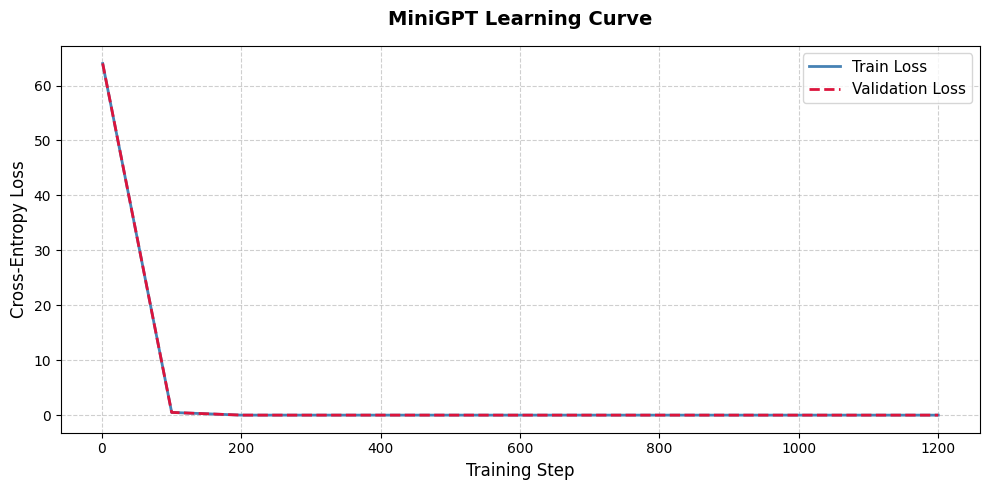

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(steps, train_losses, label="Train Loss", color="steelblue", linewidth=2)
ax.plot(steps, val_losses, label="Validation Loss", color="crimson", linewidth=2, linestyle="--")

ax.set_xlabel("Training Step", fontsize=12)
ax.set_ylabel("Cross-Entropy Loss", fontsize=12)
ax.set_title("MiniGPT Learning Curve", fontsize=14, fontweight="bold", pad=15)

ax.legend(fontsize=11, frameon=True)
ax.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()


In [6]:
@torch.no_grad()
def generate(prompt, max_new_tokens=200, temperature=0.8, top_k=20):
    model.eval()
    ids = [stoi.get(c, 0) for c in prompt][-BLOCK:]
    x = torch.tensor([ids], dtype=torch.long, device=DEVICE)
    for _ in range(max_new_tokens):
        logits, _ = model(x[:, -BLOCK:])
        logits = logits[:, -1, :] / max(temperature, 1e-5)
        k = min(top_k, logits.size(-1))
        vals, idx = torch.topk(logits, k)
        probs = F.softmax(vals, dim=-1)
        next_id = idx.gather(-1, torch.multinomial(probs, 1))
        x = torch.cat([x, next_id], dim=1)
    return "".join(itos[int(i)] for i in x[0].tolist())

for prompt in ["the ", "the fox ", "the dog "]:
    print("\nPROMPT:", repr(prompt))
    print(generate(prompt))



PROMPT: 'the '
the quick brown fox jumps over the lazy dog. the fox is quick and the dog is lazy. the quick brown fox jumps over the lazy dog. the fox is quick and the dog is lazy. the quick brown fox jumps over the laz

PROMPT: 'the fox '
the fox is quick and the dog is lazy. the quick brown fox jumps over the lazy dog. the fox is quick and the dog is lazy. the quick brown fox jumps over the lazy dog. the fox is quick and the dog is lazy. the 

PROMPT: 'the dog '
the dog is lazy. the quick brown fox jumps over the lazy dog. the fox is quick and the dog is lazy. the quick brown fox jumps over the lazy dog. the fox is quick and the dog is lazy. the quick brown fox jumps
